In [62]:
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [ ]:
#Activate only need to download data
#from utils.data_loader import download_data
#tickers = "IWY"
#df = download_data(tickers, "2005-01-01", "2025-01-01", save_path=f"data/{tickers}.parquet")
#print(df.head())

In [63]:
def load_data(filepath, ticker, start_date=None, end_date=None):
    price = pd.read_parquet(filepath)
    df = price[['Open', 'High', 'Low', 'Close']].dropna()
    
    # Date Validation
    data_start = df.index.min()
    if start_date and pd.Timestamp(start_date) < data_start:
        print(f"[SKIP] {ticker}: data starts {data_start.date()}, requested {start_date}")
        return None, None  # return None to run_backtest
    
    if start_date:
        df = df[df.index >= pd.Timestamp(start_date)]
    if end_date:
        df = df[df.index <= pd.Timestamp(end_date)]

    monthly = df['Close'].groupby(pd.Grouper(freq="MS")).nth(0)
    return df, monthly

In [64]:
def calc_portfolio(df, monthly, investment):
    shares = investment / monthly
    cum_shares = shares.cumsum()
    daily_cum_shares = cum_shares.reindex(df.index, method="ffill")
    df['port_value'] = daily_cum_shares * df['Close']
    return df

In [65]:
def calc_metrics(df, monthly, investment):
    
    # Basic Metrics
    total_invested = [-investment] * len(monthly)
    final_value = total_invested.copy()
    final_value[-1] += df['port_value'].iloc[-1]
    #IRR
    monthly_irr = npf.irr(final_value)
    annualized_irr = (1 + monthly_irr) ** 12 - 1

    #CAGR 計算 (for lum sum usually, comment out for DCA)
    #CAGR formula = (final value / initial value) ^ (1 / number of years)

    #years = (df.index[-1] - df.index[0]).days / 365 #find the total years
    #cagr = (df['port_value'].iloc[-1] / investment) ** (1 / years) - 1 


    #Cash flow series
    cashflow_series = pd.Series(0.0, index=df.index)
    cashflow_series.loc[monthly.index] = investment
    df['strategy_return'] = (
        df['port_value'] - df['port_value'].shift(1) - cashflow_series
    ) / df['port_value'].shift(1)

    #Sharpe Ratio and Sortino Ratio
    ret = df['strategy_return'].dropna()
    mean_return = ret.mean()
    std_return = ret.std()

    volatility = std_return * (252 ** 0.5)
    sharpe = mean_return / std_return * (252 ** 0.5)
    downside = ret[ret < 0]
    sortino = mean_return / downside.std() * (252 ** 0.5)

    #MDD
    cum_max = df['port_value'].cummax()
    mdd = (df['port_value'] / cum_max - 1).min()

#return all metrics as a dictionary
    return {
        "Total Invested": sum(total_invested),
        "Final Value":    final_value[-1],
        "IRR":            annualized_irr,
        #"CAGR":           cagr,
        "Volatility":     volatility,
        "Sharpe":         sharpe,
        "Sortino":        sortino,
        "MDD":            mdd,
    }

In [66]:
def run_backtest(ticker, start_date=None, end_date=None, investment=1000):
    filepath = f"data/{ticker}.parquet"
    df, monthly = load_data(filepath, ticker, start_date, end_date)
    if df is None:
        return None, None
    df = calc_portfolio(df, monthly, investment)
    metrics = calc_metrics(df, monthly, investment)
    return metrics, df

In [67]:
tickers = ["SPY", "QQQ", "IWY"]
start = "2015-01-01"
end = "2025-01-01"

metrics_dict = {}
df_dict = {}

for ticker in tickers:
    m, df = run_backtest(ticker, start, end)
    if m is None:
        continue
    metrics_dict[ticker] = m
    df_dict[ticker] = df

pd.DataFrame(metrics_dict)

,SPY,QQQ,IWY
Total Invested,"-120,000.00","-120,000.00","-120,000.00"
Final Value,"256,240.21","334,890.28","337,098.27"
IRR,0.15,0.20,0.20
Volatility,0.18,0.22,0.20
Sharpe,0.78,0.88,0.92
Sortino,0.95,1.12,1.15
MDD,-0.33,-0.31,-0.30


In [68]:
def calc_rolling(df_dict, window=252):
    result = {}
    for ticker, df in df_dict.items():
        ret = df['strategy_return'].dropna()
        result[ticker] = {
            "sharpe": ret.rolling(window).apply(lambda x: x.mean() / x.std() * (252 ** 0.5)),
            "volatility": ret.rolling(window).std() * (252 ** 0.5),
            # add one line here for other metrics like MDD、Sortino
        }
    return result

In [69]:
rolling = calc_rolling(df_dict)

rolling_sharpe_df = pd.DataFrame({t: rolling[t]["sharpe"] for t in rolling}).dropna()
rolling_vol_df    = pd.DataFrame({t: rolling[t]["volatility"] for t in rolling}).dropna()

print (rolling_sharpe_df.describe())
for ticker in rolling_sharpe_df.columns:
    s = rolling_sharpe_df[ticker]
    print(f"{ticker} | max: {s.idxmax().date()} ({s.max():.2f}) | min: {s.idxmin().date()} ({s.min():.2f})")
print (rolling_vol_df.describe())
for ticker in rolling_vol_df.columns:
    s = rolling_vol_df[ticker]
    print(f"{ticker} | max: {s.idxmax().date()} ({s.max():.2f}) | min: {s.idxmin().date()} ({s.min():.2f})")

           SPY      QQQ      IWY
count 2,264.00 2,264.00 2,264.00
mean      1.08     1.08     1.17
std       0.96     0.92     0.99
min      -0.79    -1.17    -1.12
25%       0.35     0.36     0.41
50%       0.95     1.22     1.13
75%       1.89     1.78     1.91
max       3.60     3.15     4.14
SPY | max: 2018-01-23 (3.60) | min: 2022-12-28 (-0.79)
QQQ | max: 2018-01-23 (3.15) | min: 2022-12-28 (-1.17)
IWY | max: 2018-01-23 (4.14) | min: 2022-12-28 (-1.12)
           SPY      QQQ      IWY
count 2,264.00 2,264.00 2,264.00
mean      0.17     0.21     0.19
std       0.07     0.07     0.07
min       0.07     0.10     0.08
25%       0.12     0.17     0.15
50%       0.15     0.20     0.17
75%       0.19     0.24     0.23
max       0.34     0.36     0.35
SPY | max: 2021-02-02 (0.34) | min: 2017-12-28 (0.07)
QQQ | max: 2021-02-02 (0.36) | min: 2017-12-14 (0.10)
IWY | max: 2021-02-02 (0.35) | min: 2017-12-14 (0.08)


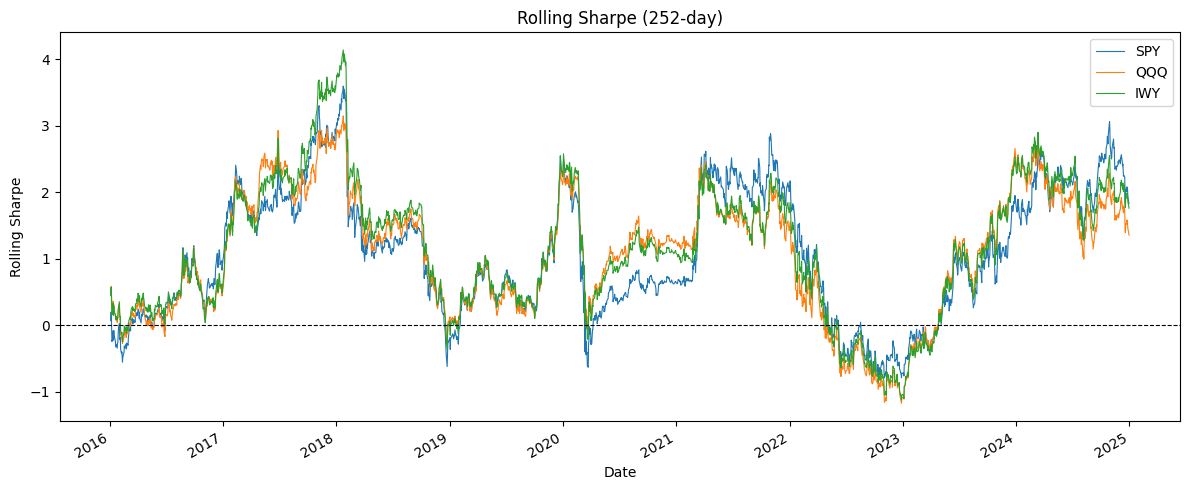

In [70]:
import matplotlib.dates as mdates

ax = rolling_sharpe_df.plot(    #change this varible to plot others metrics
    figsize=(12, 5),
    title="Rolling Sharpe (252-day)",
    linewidth=0.8
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Rolling Sharpe")

plt.tight_layout()
plt.show()

In [71]:
# Summary (2015-2025, $1000/month DCA)
# IWY: Best risk-adjusted return (highest Sharpe mean, highest max)
# QQQ: Highest absolute return (IRR 19%) but worst downside (min -1.17)
# All three peaked 2018-01, bottomed 2022-12 → rate hike cycle visible in rolling Sharpe
# SPY: Most stable, suitable as baseline